# 02 · Dataset Construction & Target Analysis

Here we (a) **define the target**, (b) assemble the model-ready table with the
`src` pipeline, and (c) study how the target relates to the features — the
"influence" analysis. Every decision here is recorded in `docs/DECISION_LOG.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from loan_default.config import load_config
from loan_default.data_loading import load_servicing
from loan_default.dataset import build_model_ready, build_target

sns.set_theme(style="whitegrid")
cfg = load_config()

## 1. Defining the target — what is a "default"?

We are not given a label. The servicing table gives us `final_loan_status` and
`max_dpd_ever`. Our definition:

> **default = 1** if `final_loan_status ∈ {Written-Off, Defaulted}` **or**
> `max_dpd_ever ≥ 90`. **default = 0** if `Closed-Good`. `Active` loans are
> **excluded** — they have not matured, so their outcome is unknown (censored).

**Why:** we want to rank *credit risk*. A charge-off is the unambiguous bad
outcome; a 90+ DPD event is the industry-standard definition of default and
catches loans that were seriously delinquent even if later cured. Including
`Active` loans as "good" would mislabel future defaulters that simply haven't
gone bad *yet*. Alternatives considered are in the decision log.

In [2]:
srv = load_servicing(cfg)
target = build_target(srv, cfg)   # only the labelled (matured) loans: default 1/0
n_active = srv["final_loan_status"].isin(cfg["target"]["exclude_statuses"]).sum()

print("Label distribution across ALL servicing records:")
print(target["default"].value_counts().rename({0: "good (0)", 1: "default (1)"}).to_string())
print(f"excluded (Active)   {n_active}")

Label distribution across ALL servicing records:
default
good (0)       4435
default (1)     878
excluded (Active)   5211


## 2. Build the model-ready dataset

`build_model_ready` runs the full pipeline: clean → customer master →
point-in-time bureau → product/branch → engineered ratios → target. We pass
`keep_diagnostics=True` here so we can *inspect* the outcome columns; they are
never in the model's feature set.

In [3]:
df = build_model_ready(cfg, keep_diagnostics=True)
print(f"Model-ready rows: {len(df):,}")
print(f"Overall default rate: {df['default'].mean():.1%}")
df.head(3)

Model-ready rows: 5,313
Overall default rate: 16.5%


,application_id,customer_id,application_date,requested_amount,loan_term_months,declared_income,employment_type,emirate,product_id,branch_id,...,dbr,dbr_above_threshold,default,final_loan_status,max_dpd_ever,num_late_payments_total,was_restructured,recovery_amount,managing_unit,product_name
0,APP-501687,CUST-101269,2021-01-01,125100.0,60,9586.0,Salaried,Sharjah,PRD-01,BR-SHJ1,...,0.624690,1.0,0,Closed-Good,24.0,2.0,False,0.0,Standard Servicing,Personal Loan Standard
1,APP-500198,CUST-100157,2021-01-01,139100.0,24,13758.0,Salaried,Abu Dhabi,PRD-01,BR-AUH1,...,0.607289,1.0,0,Closed-Good,11.0,2.0,False,0.0,Standard Servicing,Personal Loan Standard
2,APP-503046,CUST-102299,2021-01-02,60200.0,36,10496.0,Salaried,Dubai,PRD-03,BR-DXB2,...,0.470259,0.0,0,Closed-Good,19.0,3.0,False,0.0,Standard Servicing,Salary Advance


In [11]:
df.columns

Index(['application_id', 'customer_id', 'application_date', 'requested_amount',
       'loan_term_months', 'declared_income', 'employment_type', 'emirate',
       'product_id', 'branch_id', 'channel', 'app_form_version',
       'employer_missing', 'emirate_was_channel', 'age', 'gender',
       'nationality_group', 'marital_status', 'dependents_count',
       'bureau_score', 'num_inquiries_last_3m', 'total_outstanding_debt',
       'num_dpd_90_last_12m', 'has_long_tenor_loan', 'has_bureau_pull',
       'interest_rate_band', 'branch_type', 'loan_to_income', 'debt_to_income',
       'installment_to_income', 'dbr', 'dbr_above_threshold', 'default',
       'final_loan_status', 'max_dpd_ever', 'num_late_payments_total',
       'was_restructured', 'recovery_amount', 'managing_unit', 'product_name'],
      dtype='object')

## 3. Target vs features — which signals move default risk?

### 3a. Bureau score (expected to be the strongest single signal)

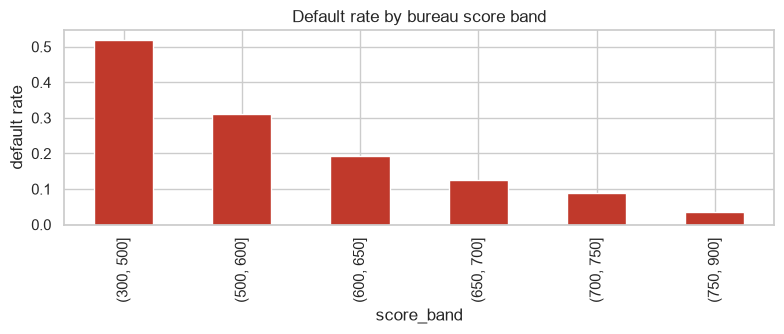

In [4]:
d = df.copy()
d["score_band"] = pd.cut(d["bureau_score"], [300, 500, 600, 650, 700, 750, 900])
rate = d.groupby("score_band", observed=True)["default"].mean()
ax = rate.plot(kind="bar", figsize=(8, 3.5), color="#c0392b")
ax.set_ylabel("default rate"); ax.set_title("Default rate by bureau score band")
plt.tight_layout(); plt.show()

### 3b. Categorical drivers — employment, product, channel, emirate

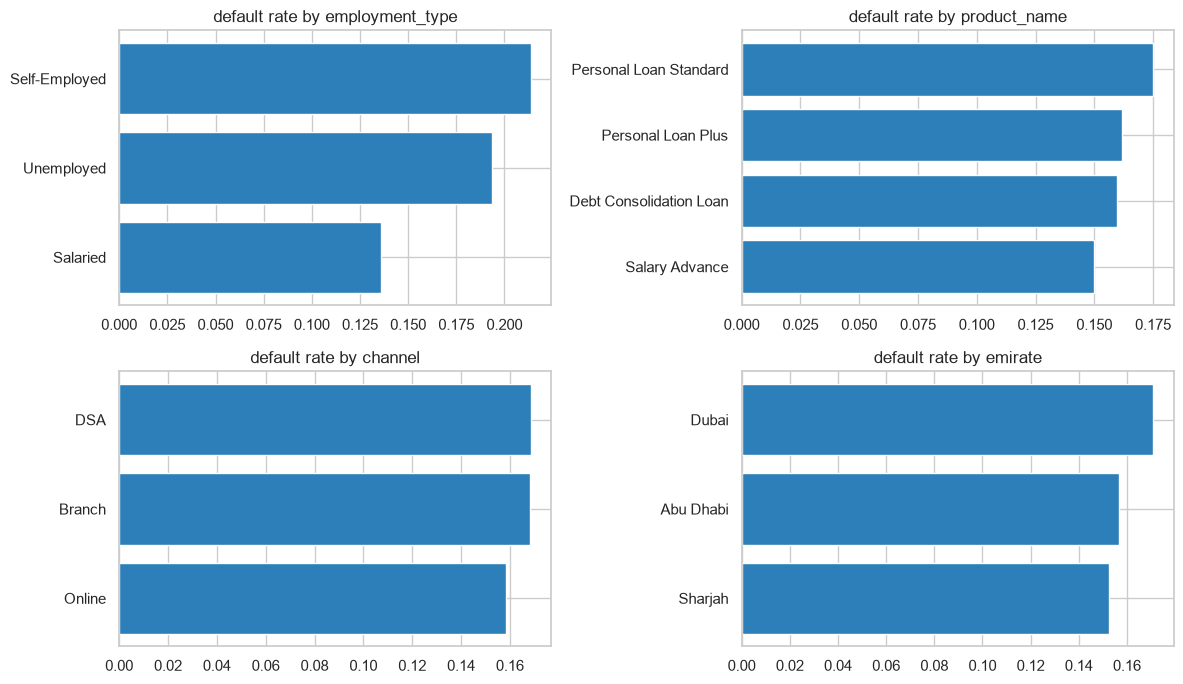

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), ["employment_type", "product_name", "channel", "emirate"]):
    g = df.groupby(col, observed=True)["default"].agg(["mean", "size"]).sort_values("mean")
    ax.barh(g.index.astype(str), g["mean"], color="#2c7fb8")
    ax.set_title(f"default rate by {col}"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

### 3c. Engineered affordability ratios — debt-to-income & loan-to-income

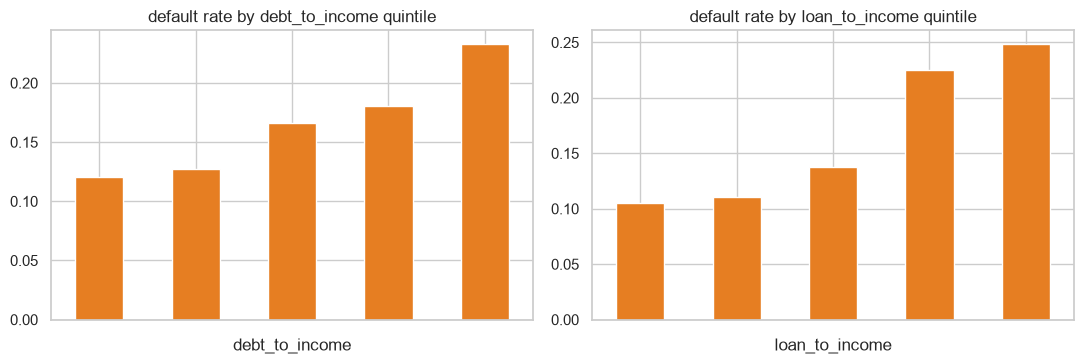

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, col in zip(ax, ["debt_to_income", "loan_to_income"]):
    band = pd.qcut(df[col].clip(upper=df[col].quantile(0.99)), 5, duplicates="drop")
    df.groupby(band, observed=True)["default"].mean().plot(kind="bar", ax=a, color="#e67e22")
    a.set_title(f"default rate by {col} quintile"); a.set_xticklabels([])
plt.tight_layout(); plt.show()

### 3c-bis. Debt Burden Ratio (DBR) — the UAE affordability metric

DBR = monthly debt repayments / monthly income. The UAE Central Bank caps
retail DBR at **50%**, so `dbr_above_threshold` encodes a real regulatory risk
line. We expect risk to climb with DBR and to jump above the 0.50 cap.

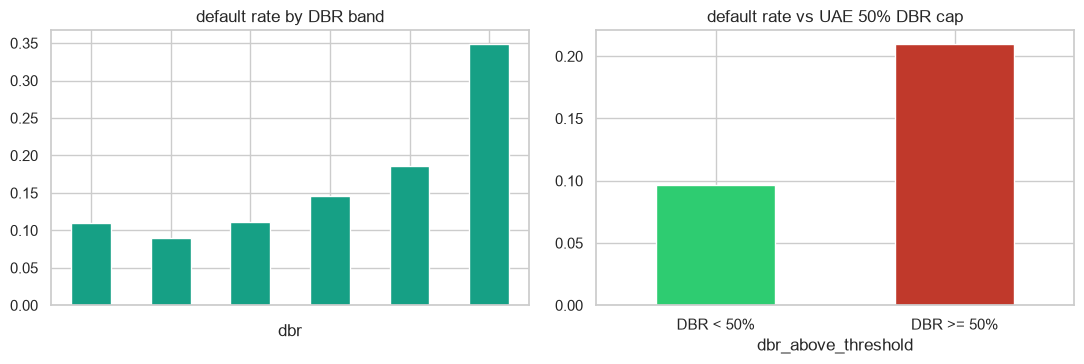

default rate  DBR>=50%: 21.0%  |  DBR<50%: 9.6%


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
band = pd.qcut(df["dbr"].clip(upper=df["dbr"].quantile(0.99)), 6, duplicates="drop")
df.groupby(band, observed=True)["default"].mean().plot(kind="bar", ax=ax[0], color="#16a085")
ax[0].set_title("default rate by DBR band"); ax[0].set_xticklabels([])
rates = df.groupby("dbr_above_threshold", observed=True)["default"].mean()
rates.plot(kind="bar", ax=ax[1], color=["#2ecc71", "#c0392b"])
ax[1].set_xticklabels(["DBR < 50%", "DBR >= 50%"], rotation=0)
ax[1].set_title("default rate vs UAE 50% DBR cap")
plt.tight_layout(); plt.show()
print(f"default rate  DBR>=50%: {rates.get(1.0, float('nan')):.1%}  |  "
      f"DBR<50%: {rates.get(0.0, float('nan')):.1%}")

### 3d. Numeric correlation with the target

A quick point-biserial view: which numeric features move most with default.

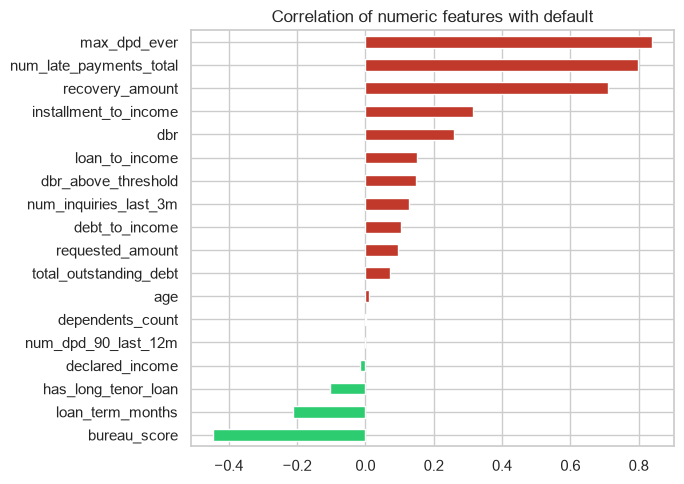

In [8]:
num = df.select_dtypes("number").drop(columns=["default"], errors="ignore")
corr = num.apply(lambda c: c.corr(df["default"])).dropna().sort_values()
ax = corr.plot(kind="barh", figsize=(7, 5), color=np.where(corr < 0, "#2ecc71", "#c0392b"))
ax.set_title("Correlation of numeric features with default"); plt.tight_layout(); plt.show()

**Reading it:** higher bureau score → lower default (strong negative). Higher
DPD history, more inquiries, higher debt-to-income and loan-to-income → higher
default. These signs match credit intuition, which is a good sanity check that
the joins and cleaning are correct and there is no obvious leakage.

## 4. Leakage check — outcome columns must not correlate "too perfectly"

The servicing columns (`max_dpd_ever`, `recovery_amount`, …) correlate almost
perfectly with the target *by construction*. That is exactly why they are
excluded from features. We show it to make the exclusion explicit.

In [9]:
leak = ["max_dpd_ever", "num_late_payments_total", "recovery_amount"]
print(df[leak + ["default"]].corr()["default"].round(3))
print("\nThese are OUTCOMES — excluded from FEATURE_COLUMNS. See dataset.py.")

max_dpd_ever               0.839
num_late_payments_total    0.797
recovery_amount            0.710
default                    1.000
Name: default, dtype: float64

These are OUTCOMES — excluded from FEATURE_COLUMNS. See dataset.py.
